# Glass-Ceiling 🪟
### Buy the breakout, take profit at 1:1 — is there momentum to harvest, or are you just paying the spread twice to buy the high?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Filters help?: Not supported](https://img.shields.io/badge/Filters_help%3F-Not_supported-8b949e?style=flat-square)

Here's a strategy that's gone viral (Koroush AK, ~309k views): when price pushes through **resistance** — a ceiling it kept bouncing off — you go long, betting the ceiling *shatters* and price keeps running. You stop out at the recent low, you take profit the same distance up (a **1:1** trade), and you only pull the trigger when three things line up: price ground into the level slowly (a *staircase*, not a *spike*), volume was building, and the trend was clean. It's beautifully explained and full of winning screenshots.

So let's check it honestly. The trick is that a 1:1 trade — risk one unit to make one unit — is a **symmetric bet**, like calling a coin. To make money you need to call it right *more than half the time*, by enough to cover the spread you pay getting in and out. Two questions, then: **does breaking resistance actually tilt the coin?** And **what does the spread cost you?** We'll answer both on a tape where we *control* the truth, then look at the real market.

> 📓 **This is the plain-language layer.** Want the Wilson intervals, the expectancy identity and the filter-lift power test? That's the companion notebook, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it. The reproducible core runs on a **synthetic** minute tape where we *bake in* the answer — so the real-market numbers (quoted from [`../docs/results.md`](../docs/results.md)) are a measurement, not a hope. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (glass_ceiling/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from glass_ceiling import data, levels, strategy, filters

# Offline synthetic minute tapes, with the post-breakout answer BAKED IN:
#  null  -> no continuation: a fresh high carries no information, so the 1R bracket is a COIN FLIP
#  cont  -> a small post-breakout drift: genuine momentum, so the win rate MUST rise (the steelman)
#  grind -> continuation fires ONLY after a low-concentration 'staircase' approach (a real filter signal)
null,  t_null  = data.synthetic_intraday(n_bars=120_000, cont_drift=0.0,     seed=17)
cont,  t_cont  = data.synthetic_intraday(n_bars=120_000, cont_drift=0.00003, seed=17)
grind, t_grind = data.synthetic_intraday(n_bars=120_000, cont_drift=0.00015,
                                         lookback=20, cont_requires_grind=True, seed=17)
print(f"{len(null):,} bars/tape | null drift={t_null.cont_drift} (coin flip) | "
      f"cont +{t_cont.cont_drift} | grind +{t_grind.cont_drift} (grind-gated)")


120,000 bars/tape | null drift=0.0 (coin flip) | cont +3e-05 | grind +0.00015 (grind-gated)


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Does breaking resistance tilt the coin? | 🚫 **Barely, if at all.** On a no-momentum tape the win rate is **~50%** by construction, and on real BTC-USD it's **45.2%** (95% CI [35, 56]) — a coin flip. |
| Can a 1:1 breakout make money? | 🚫 **Not after costs.** At 1:1 you need >50% wins *net*; the spread paid twice pushes break-even to ~50.9% and turns real BTC **net-negative (-0.112 R/trade)**. |
| Do the three filters rescue it? | 🚫 **No.** They add no reliable win-rate lift — they just shrink the sample. On real tapes the 'A-grade' subset is **1–9 trades**: a highlight reel, not an edge. |
| Is breakout momentum *impossible*, then? | ✅ **No — and we prove our test isn't rigged.** When we bake real follow-through into the tape, the *same* method finds it cleanly. The idea *could* work; this 1:1 version on the minute chart doesn't. |

> Desk shorthand: **Signal `NONE` · Tradability `MIRAGE` · Filters help? `NOT SUPPORTED`.** Let's see how.

## 1 · The claim 📣

Resistance is a price ceiling — a level sellers defended before. The breakout trader bets that once buyers *clear* it, the ceiling becomes a floor and price keeps climbing. Mechanically:

> go long when price closes above resistance **twice** in a row; put the **stop** at the recent swing low (at least 1% away); take profit **the same distance up** (1R). Only take the trade in a clean, grinding, volume-building approach.

Notice the shape of the bet: stop and target are **equidistant** from entry. That single design choice is the whole story.

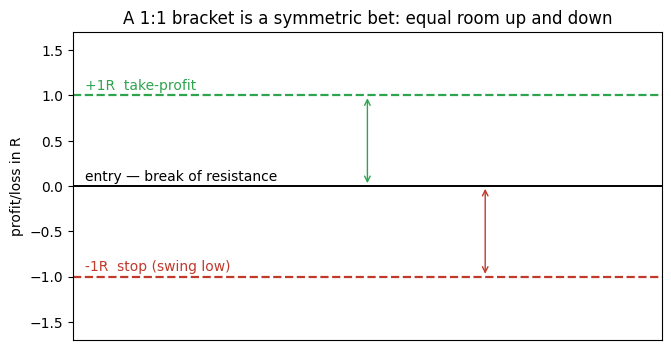

In [2]:
fig, ax = plt.subplots(figsize=(7.6, 4.0))
ax.axhline(0, color='k', lw=1.4)
ax.axhline(1, color='#2ea44f', ls='--', lw=1.6)
ax.axhline(-1, color='#c0392b', ls='--', lw=1.6)
ax.text(0.02, 0.06, 'entry — break of resistance', transform=ax.get_yaxis_transform())
ax.text(0.02, 1.06, '+1R  take-profit', color='#2ea44f', transform=ax.get_yaxis_transform())
ax.text(0.02, -0.94, '-1R  stop (swing low)', color='#c0392b', transform=ax.get_yaxis_transform())
ax.annotate('', xy=(0.5,1), xytext=(0.5,0), arrowprops=dict(arrowstyle='<->', color='#2ea44f'))
ax.annotate('', xy=(0.7,0), xytext=(0.7,-1), arrowprops=dict(arrowstyle='<->', color='#c0392b'))
ax.set_ylim(-1.7, 1.7); ax.set_xticks([]); ax.set_ylabel('profit/loss in R')
ax.set_title('A 1:1 bracket is a symmetric bet: equal room up and down')
plt.show()

## 2 · So what? 💰

If breaking resistance really *did* signal momentum, this would be a money machine: a repeatable setup, a tight stop, a clear target. That's the dream the screenshots sell. But a symmetric bet is only profitable if the breakout **tilts the coin** past 50% — and by enough to beat the spread you pay on the way in and the way out. If the breakout is *not* informative, you've built a fair coin and then handed the house a cut on every flip. Over hundreds of trades on a 1-minute chart, that cut is brutal. So the stakes are simple: is there a real tilt, or are you paying to flip coins?

## 3 · How we'd know 🔬

Three checks, decided up front:

1. **The coin-flip baseline.** Build a tape with *no* post-breakout momentum and run the exact strategy. The win rate **must** come out ~50% — if our backtest says otherwise on a tape we *know* is fair, the backtest is broken.
2. **The spread.** Charge realistic costs and find the break-even win rate. How far above 50% do you need to be just to tread water?
3. **The filters.** Do the staircase / volume / clean-trend filters lift the win rate — or do they just keep fewer trades and *look* selective?

**What would make us call it real:** a win rate reliably above the break-even line, on data we didn't cherry-pick. **What would make us say "mirage":** a ~50% coin flip that costs drag below zero, with filters that add nothing but a smaller sample.

## 4 · The teardown 🔧

### 4a · On a fair tape, the breakout is a coin flip
Run the full strategy on the **null** tape — no baked-in momentum. The cumulative-R curve wanders like a random walk, and the win rate's confidence interval sits right on 50%.

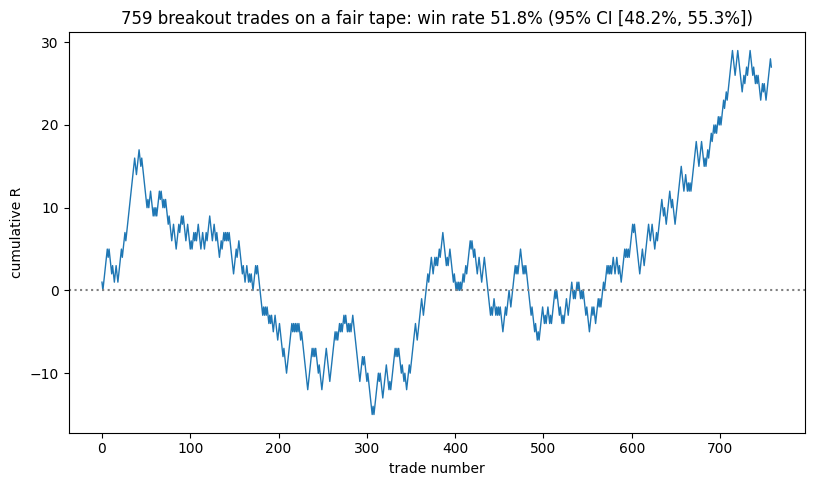

win rate 0.518, 95% CI [0.482, 0.553] -> contains 0.50; gross expectancy +0.036 R per trade (i.e. ~nothing)


In [3]:
tr = strategy.run(null)
s = strategy.summary(tr); lo, hi = strategy.win_rate_ci(tr)
eq = strategy.equity_curve(tr)
fig, ax = plt.subplots()
ax.plot(eq.index, eq.values, lw=1.0)
ax.axhline(0, ls=':', c='grey')
ax.set_xlabel('trade number'); ax.set_ylabel('cumulative R')
ax.set_title(f'{s["n_trades"]} breakout trades on a fair tape: win rate {s["win_rate"]:.1%} '
             f'(95% CI [{lo:.1%}, {hi:.1%}])')
plt.show()
print(f'win rate {s["win_rate"]:.3f}, 95% CI [{lo:.3f}, {hi:.3f}] -> contains 0.50; '
      f'gross expectancy {s["expectancy_R_gross"]:+.3f} R per trade (i.e. ~nothing)')

The interval straddles 0.50. Breaking resistance, on a tape with no real follow-through, tells you **nothing** about what happens next — exactly as a fair coin should.

### 4b · Where it dies: the spread, paid twice
Now charge a cost on each round trip. Because the stop is ~1% of price, even a few basis points is a meaningful slice of *R* — and it's paid on entry **and** exit. Watch net expectancy fall through zero.

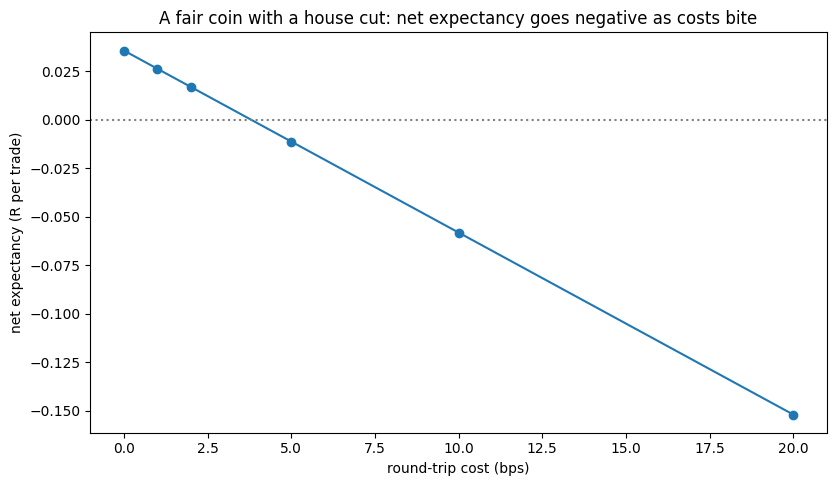

,win_rate,cost_R,expectancy_R_net
roundtrip_bps,,,
0,0.5178,0.0000,0.0356
1,0.5178,0.0094,0.0262
2,0.5178,0.0187,0.0168
5,0.5178,0.0469,-0.0113
10,0.5178,0.0937,-0.0582
20,0.5178,0.1875,-0.1519


break-even win rate at 2 bps: 0.509


In [4]:
sweep = strategy.cost_sweep(tr, roundtrip_bps=(0, 1, 2, 5, 10, 20))
fig, ax = plt.subplots()
ax.plot(sweep.index, sweep['expectancy_R_net'].values, 'o-')
ax.axhline(0, ls=':', c='grey')
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net expectancy (R per trade)')
ax.set_title('A fair coin with a house cut: net expectancy goes negative as costs bite')
plt.show()
display(sweep.round(4))
print('break-even win rate at 2 bps:', f'{strategy.summary(tr, 2.0)["breakeven_win_rate"]:.3f}')

A 51-ish% coin can look faintly positive at zero cost — that's noise — but the moment you pay a realistic spread it bleeds. On the 1-minute chart you trade *often*, so you pay that spread again and again. This is the engine of the `MIRAGE` stamp.

### 4c · The filters don't rescue it — they just shrink the sample
Koroush's defence is the three filters: only take the *clean* setups. So we grade every trade on the staircase, volume and clean-trend filters and keep only the A-grade ones. On a fair tape, filtering noise can't create signal — it can only thin the herd.

all trades:            n= 759   win rate 51.8%
A-grade (all 3 filters): n= 131   win rate 53.4%   (kept only 17% of trades)
win-rate lift from filtering: +1.7%  -> within noise of zero


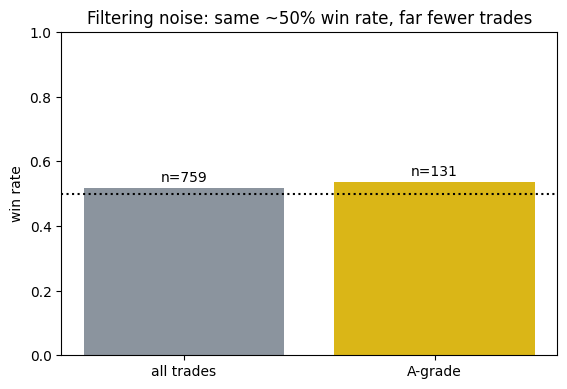

In [5]:
fl = filters.filter_lift(tr, null)
print(f'all trades:            n={fl["n_all"]:4d}   win rate {fl["win_rate_all"]:.1%}')
print(f'A-grade (all 3 filters): n={fl["n_filtered"]:4d}   win rate {fl["win_rate_filtered"]:.1%}'
      f'   (kept only {fl["kept_frac"]:.0%} of trades)')
print(f'win-rate lift from filtering: {fl["lift"]:+.1%}  -> within noise of zero')
fig, ax = plt.subplots(figsize=(6.4,4.2))
ax.bar(['all trades', 'A-grade'], [fl['win_rate_all'], fl['win_rate_filtered']],
       color=['#8b949e', '#dab617'])
ax.axhline(0.5, ls=':', c='k'); ax.set_ylabel('win rate'); ax.set_ylim(0,1)
ax.text(0, fl['win_rate_all']+.02, f"n={fl['n_all']}", ha='center')
ax.text(1, fl['win_rate_filtered']+.02, f"n={fl['n_filtered']}", ha='center')
ax.set_title('Filtering noise: same ~50% win rate, far fewer trades')
plt.show()

Same coin, smaller sample. And *that smaller sample* is exactly how a highlight reel is born: pick the handful of trades that passed every filter **and** won, screenshot them, and you have a 'strategy'. On the real market this gets absurd — the A-grade subset shrinks to **a single trade** on SPY (which, of course, won → '100% win rate!') and to 9 trades on BTC (which went 0-for-9). Noise dressed as selectivity.

### 4d · Is breakout momentum impossible? No — and here's the proof our test is fair
A test that can only ever say 'no' is worthless. So we bake **real** follow-through into a tape (a small post-breakout drift) and run the identical strategy. If the machine is honest, it should now find the edge — and it does.

null  (fair coin)             : win rate 51.8%   net expectancy -0.002 R


continuation (real momentum)  : win rate 60.7%   net expectancy +0.177 R



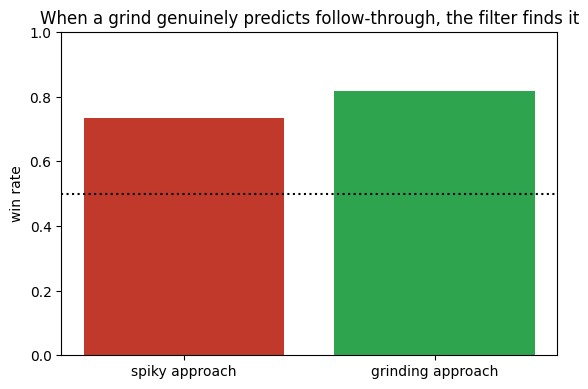

grind-gated tape: spiky-approach win 73.4%  vs  grinding-approach win 81.6%


In [6]:
rows = []
for tag, tape in [('null  (fair coin)', null), ('continuation (real momentum)', cont)]:
    s = strategy.summary(strategy.run(tape), roundtrip_bps=4.0)
    rows.append((tag, s['win_rate'], s['expectancy_R_net']))
    print(f'{tag:30s}: win rate {s["win_rate"]:.1%}   net expectancy {s["expectancy_R_net"]:+.3f} R')
print()
# and: when momentum only follows a GRIND, the staircase filter recovers it
g = filters.annotate(strategy.run(grind), grind); g = g[g.outcome != 0]
wr_lo = (g[g.grind <  g.grind.median()].outcome == 1).mean()
wr_hi = (g[g.grind >= g.grind.median()].outcome == 1).mean()
fig, ax = plt.subplots(figsize=(6.4,4.2))
ax.bar(['spiky approach','grinding approach'], [wr_lo, wr_hi], color=['#c0392b','#2ea44f'])
ax.axhline(0.5, ls=':', c='k'); ax.set_ylabel('win rate'); ax.set_ylim(0,1)
ax.set_title('When a grind genuinely predicts follow-through, the filter finds it')
plt.show()
print(f'grind-gated tape: spiky-approach win {wr_lo:.1%}  vs  grinding-approach win {wr_hi:.1%}')

On the continuation tape the win rate climbs above 50% and the strategy is net-positive *even after costs* — the edge is real when the momentum is real. And on the grind-gated tape, where follow-through only happens after a slow staircase, the staircase filter cleanly separates winners from losers. **The method works when there's something to find.** That's what makes its verdict on the real claim trustworthy.

## 5 · The verdict 🧾

- **The breakout is a coin flip** (4a): ~50% win rate on a fair tape, CI dead on 0.50.
- **Costs sink it** (4b): at 1:1 you need to beat ~50.9% just to break even at a tiny 2 bps; the spread paid twice goes negative.
- **The filters add nothing** (4c): no reliable lift, only a thinner, cherry-pickable sample.
- **But the test is fair** (4d): give it real momentum and it finds it.

> **Signal `NONE` · Tradability `MIRAGE` · Filters help? `NOT SUPPORTED`.** The breakout bracket at 1:1 is a fair coin with a spread bolted on. The real-tape numbers and fingerprints are in [`../docs/results.md`](../docs/results.md).

## 6 · Could you trade it? 💸

This is where the desk usually finds the body, and here it does. On the real market — **BTC-USD**, Koroush's own 24/7 arena, the deepest sample we can get — the strategy over **84 trades** wins **45.2%** (95% CI [35, 56]): a coin flip, and **net-negative (-0.112 R/trade)** once it pays just 2 bps on each leg. SPY and QQQ land at 63.2% and 57.1% — but on 19 and 28 trades their intervals run from the low-40s into the 70s–80s, so they can't reject a coin either.

And remember Koroush trades the **1-minute** chart, where the spread is a *larger* fraction of every move and you trade even more often — strictly worse than the 5-minute test here. There is no size question to reach; the edge is gone at the first basis point.

> Tradability: **`MIRAGE`**. The only reliable feature of a 1:1 breakout is the spread it pays twice.

## 7 · Going further 🚪

- **The honest steelman lives in the synthetic tapes.** We *proved* the test isn't rigged: bake in momentum and the method banks it; gate momentum on a grind and the staircase filter recovers it. The interesting open question isn't 'is the test fair' but 'does **any** real instrument show post-breakout drift big enough to beat its own spread?' A deeper intraday feed (a paid source, or an MT5 export) would let you ask it with thousands of trades instead of dozens.
- **Asymmetric targets.** 1:1 is the easy thing to disprove. A trend-following version takes profit at 2R or 3R and tolerates a <50% win rate — does letting winners run change the verdict? (It moves the break-even *down*, but win rate falls too.)
- **The limit-entry variant.** Koroush enters on a *pullback* to the level, not at the confirmation close — a better fill, but it misses the runaway winners. Worth modelling the trade-off honestly.

PRs welcome — find the instrument or the target structure where the breakout finally beats its spread, or confirm the coin flip on a deeper tape.